In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 📚 Importing Required Libraries

In this section, we import all the necessary Python libraries for data analysis, visualization, preprocessing, and machine learning.

### Libraries Used
- Pandas and NumPy for data manipulation
- Matplotlib and Seaborn for visualization
- Scikit-Learn for machine learning
- XGBoost for advanced predictive modeling

These libraries form the foundation of the project workflow.

In [17]:
df = pd.read_excel(
    r"C:\Users\SAAD MOHAMMED\OneDrive\Desktop\Sure Trust\Maths.csv"
)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [19]:
df.shape

(397, 33)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      397 non-null    object
 1   sex         397 non-null    object
 2   age         397 non-null    int64 
 3   address     397 non-null    object
 4   famsize     397 non-null    object
 5   Pstatus     397 non-null    object
 6   Medu        397 non-null    int64 
 7   Fedu        397 non-null    int64 
 8   Mjob        397 non-null    object
 9   Fjob        397 non-null    object
 10  reason      397 non-null    object
 11  guardian    397 non-null    object
 12  traveltime  397 non-null    int64 
 13  studytime   397 non-null    int64 
 14  failures    397 non-null    int64 
 15  schoolsup   397 non-null    object
 16  famsup      397 non-null    object
 17  paid        397 non-null    object
 18  activities  397 non-null    object
 19  nursery     397 non-null    object
 20  higher    

In [22]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,16.705290,2.748111,2.521411,1.450882,2.032746,0.335013,3.944584,3.234257,3.108312,1.478589,2.289673,3.556675,5.695214,10.881612,10.687657,10.377834
std,1.279716,1.097301,1.090672,0.696840,0.838731,0.742714,0.894400,0.996476,1.112762,0.889143,1.286770,1.388967,7.988015,3.333120,3.770322,4.604928
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


##  Generating statistical summaries of numerical features.

In [23]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(2)

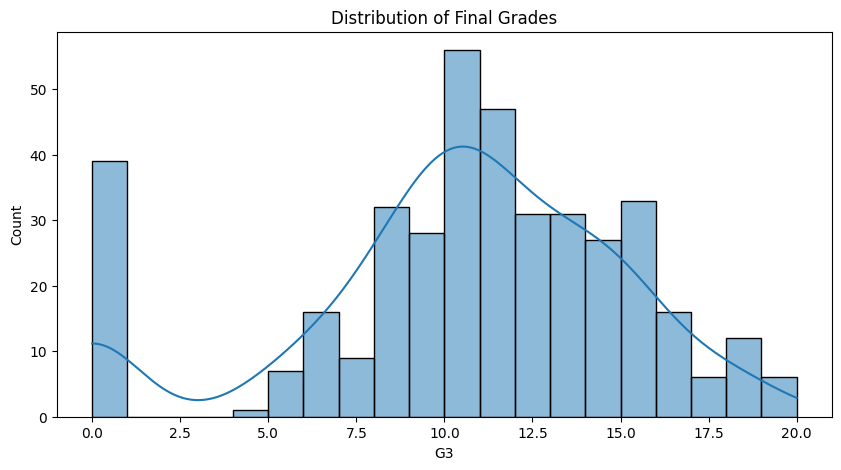

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["G3"],
    kde=True,
    bins=20
)

plt.title("Distribution of Final Grades")
plt.show()

Visualizing the distribution of final student grades.

### Observation

Most students scored between 10 and 15 marks, indicating average academic performance across the dataset.

In [26]:
from sklearn.preprocessing import LabelEncoder


df_encoded = df.copy()

for col in df_encoded.select_dtypes(include="object"):
    
    le = LabelEncoder()
    
    df_encoded[col] = le.fit_transform(
        df_encoded[col]
    )

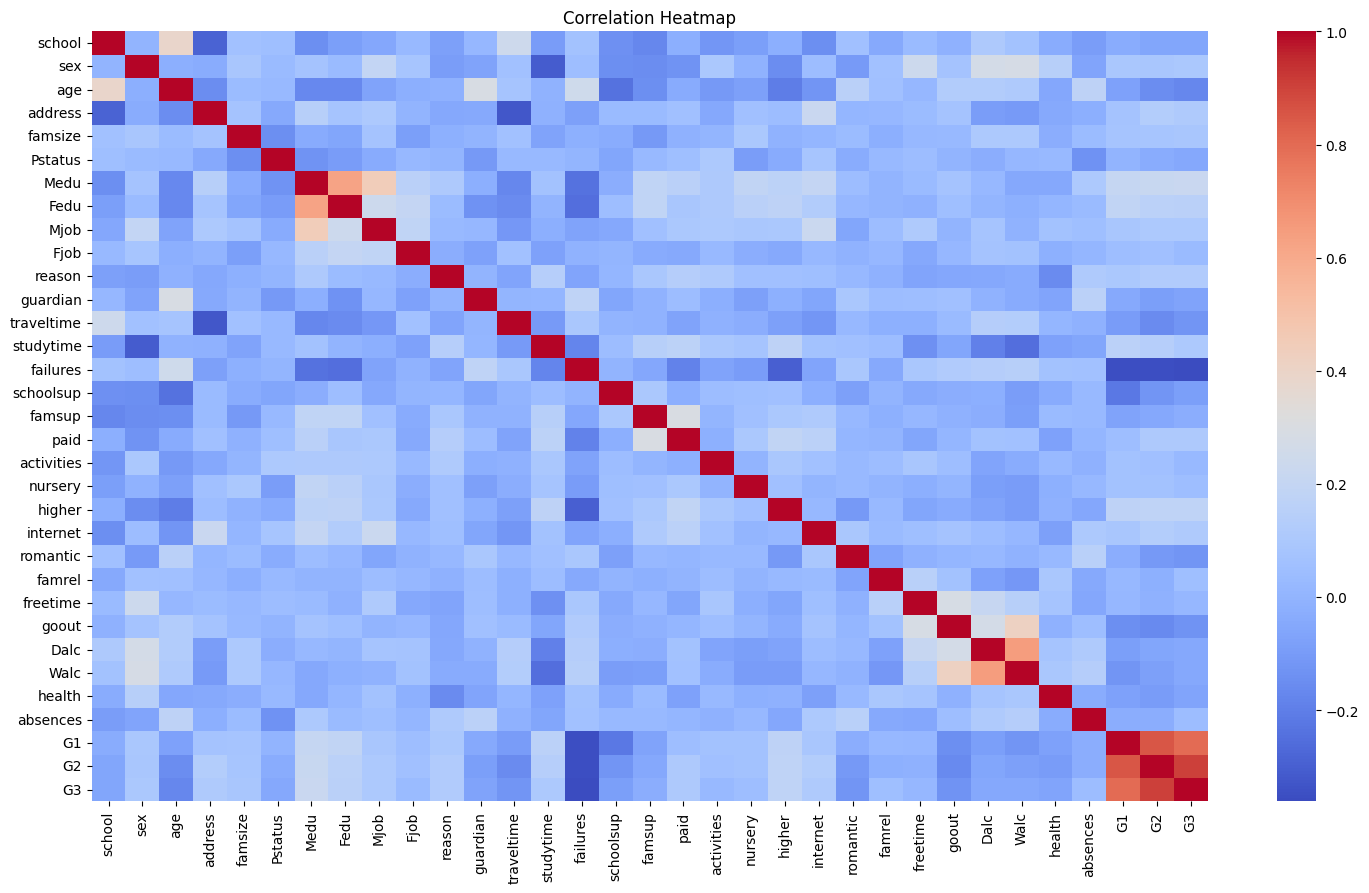

In [27]:
plt.figure(figsize=(18,10))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Analyzing correlations between features.

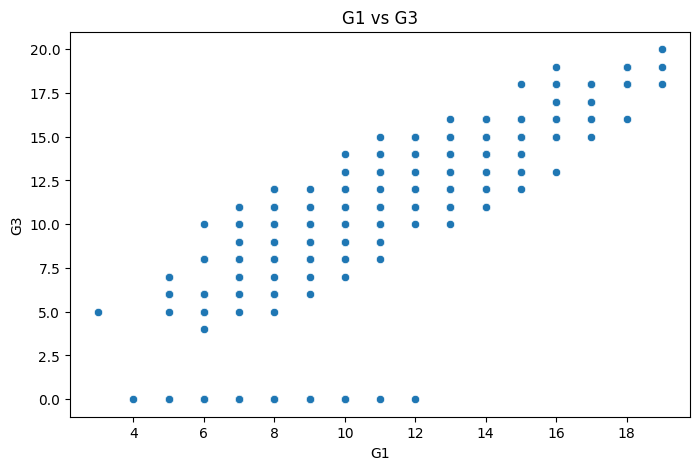

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["G1"],
    y=df["G3"]
)

plt.title("G1 vs G3")
plt.show()


Exploring the relationship between first-period and final grades.

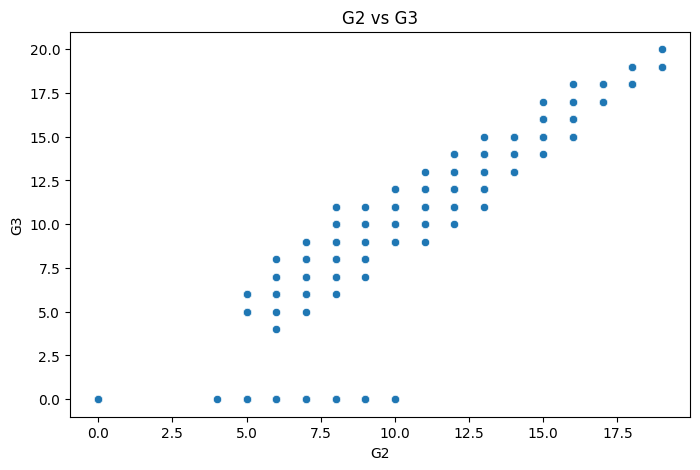

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["G2"],
    y=df["G3"]
)

plt.title("G2 vs G3")
plt.show()

Exploring the relationship between second-period and final grades.

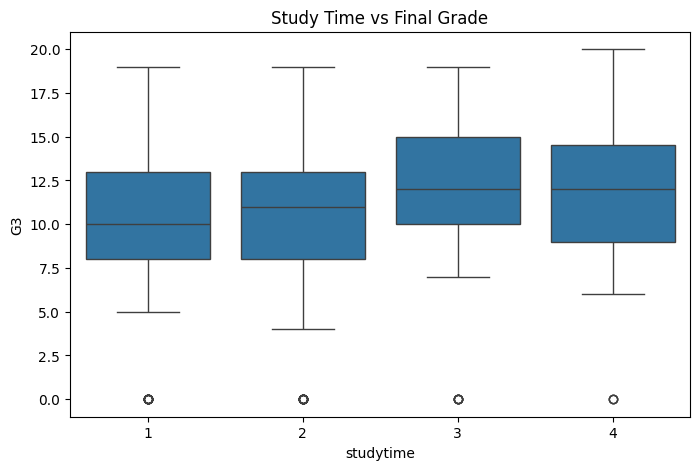

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["studytime"],
    y=df["G3"]
)

plt.title("Study Time vs Final Grade")
plt.show()

Investigating the impact of study time on performance.

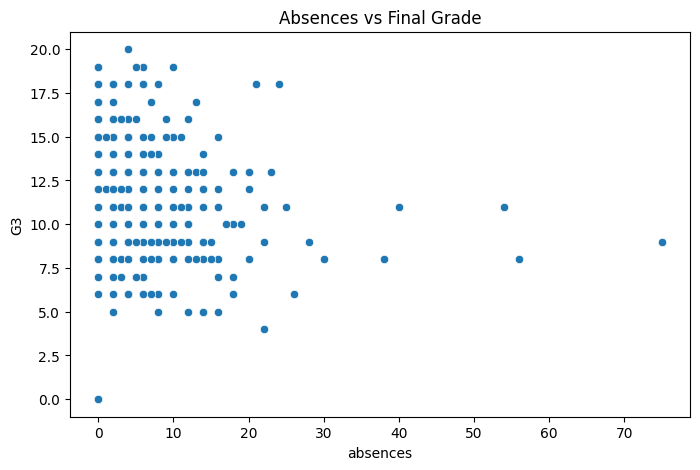

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["absences"],
    y=df["G3"]
)

plt.title("Absences vs Final Grade")
plt.show()

Examining how absences affect final grades.

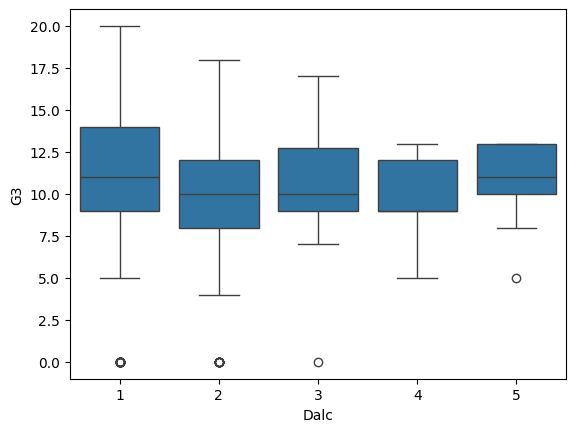

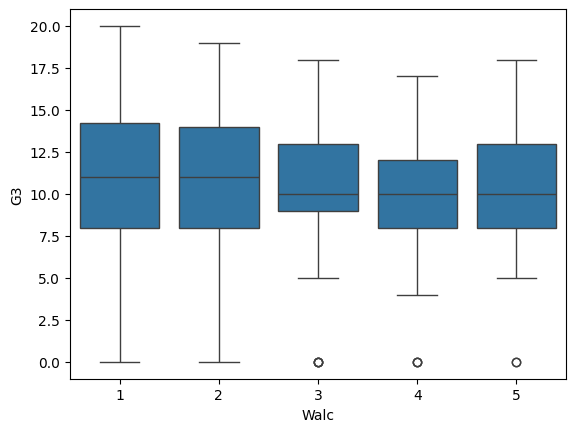

In [33]:
sns.boxplot(
    x=df["Dalc"],
    y=df["G3"]
)

plt.show()

sns.boxplot(
    x=df["Walc"],
    y=df["G3"]
)

plt.show()

Analyzing weekday and weekend alcohol consumption and academic performance.

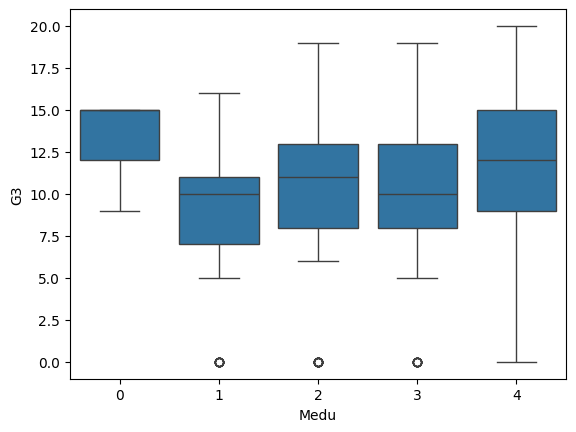

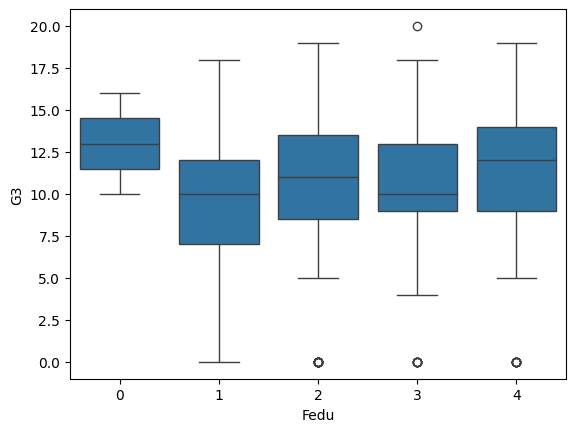

In [34]:
sns.boxplot(
    x=df["Medu"],
    y=df["G3"]
)

plt.show()

sns.boxplot(
    x=df["Fedu"],
    y=df["G3"]
)

plt.show()

Evaluating the influence of parents education on grades.

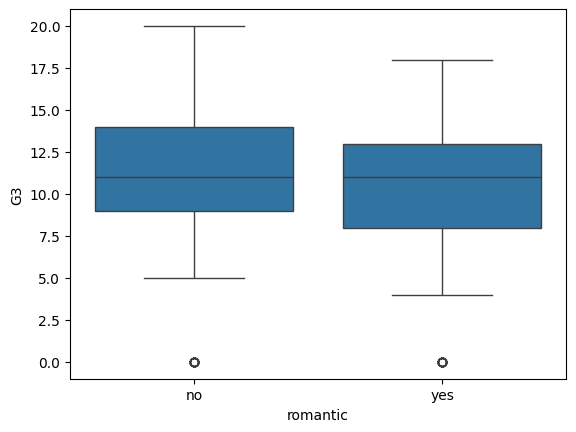

In [37]:
sns.boxplot(
    x=df["romantic"],
    y=df["G3"]
)

plt.show()

Comparing grades based on relationship status.

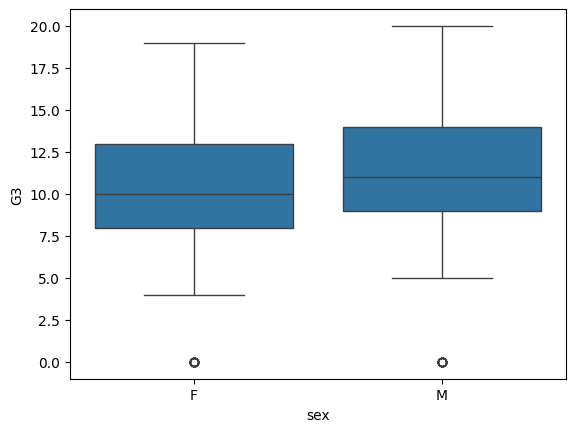

In [36]:
sns.boxplot(
    x=df["sex"],
    y=df["G3"]
)

plt.show()

Comparing grades based on gender.

In [38]:
df["At_Risk"] = np.where(
    df["G3"] < 10,
    1,
    0
)

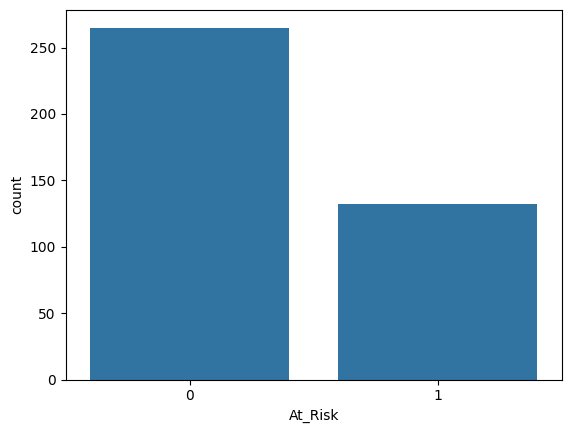

In [39]:
sns.countplot(
    x=df["At_Risk"]
)

plt.show()

Identifying students who may be academically at risk.

In [40]:
df_ml = df.copy()

for col in df_ml.select_dtypes(include="object"):
    
    le = LabelEncoder()
    
    df_ml[col] = le.fit_transform(
        df_ml[col]
    )

In [41]:
X = df_ml.drop(
    "G3",
    axis=1
)

y = df_ml["G3"]

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

In [47]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(
    "R2 Score:",
    r2_score(
        y_test,
        rf_pred
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        rf_pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            rf_pred
        )
    )
)

R2 Score: 0.9110671337409462
MAE: 0.827375
RMSE: 1.3385252560602325


### Observation

The Random Forest model achieved an R² score of 0.91, indicating strong predictive performance on unseen data.

In [48]:
importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    }
)

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

Identifying the most important predictive features.

In [49]:
from xgboost import XGBRegressor


xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

In [50]:
print(
    "R2 Score:",
    r2_score(
        y_test,
        xgb_pred
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        xgb_pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            xgb_pred
        )
    )
)

R2 Score: 0.8813227415084839
MAE: 0.9531282186508179
RMSE: 1.5462480295549572


### Observation

The XGBoost model achieved an R² score of 0.89, indicating strong predictive performance on unseen data.

In [51]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            "XGBoost"
        ],
        "R2": [
            r2_score(
                y_test,
                rf_pred
            ),
            r2_score(
                y_test,
                xgb_pred
            )
        ]
    }
)

comparison

,Model,R2
0,Random Forest,0.911067
1,XGBoost,0.881323


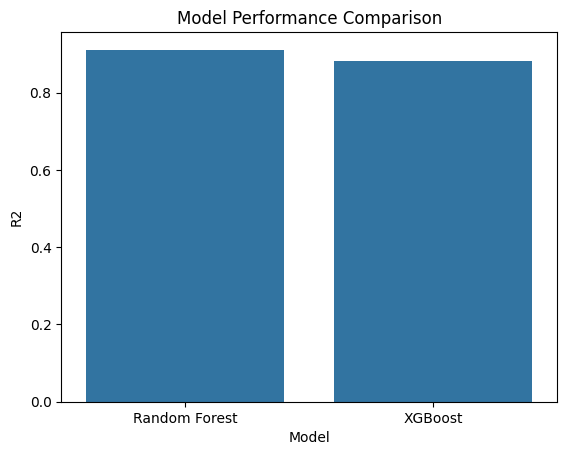

In [52]:
sns.barplot(
    data=comparison,
    x="Model",
    y="R2"
)

plt.title(
    "Model Performance Comparison"
)

plt.show()

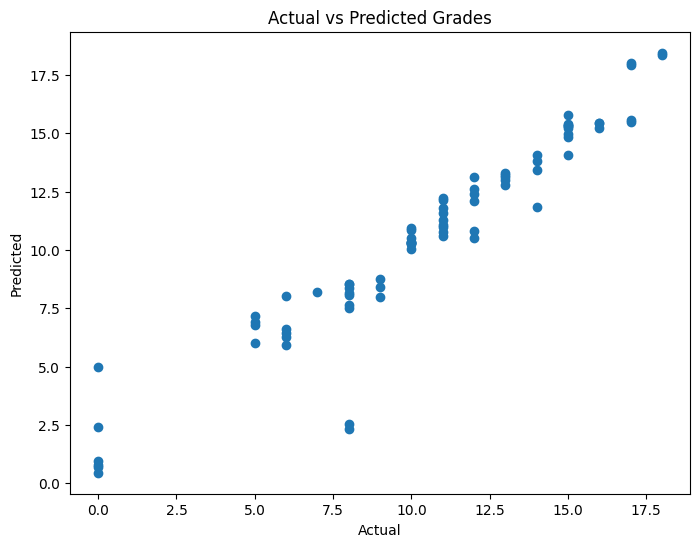

In [55]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Grades")
plt.show()

# 📌 Project Summary and Conclusion

In this project, we performed a comprehensive analysis of student academic performance and developed machine learning models to predict final exam grades.

### 🔍 Exploratory Data Analysis (EDA)

The dataset was explored to understand its structure, identify missing values, detect duplicate records, and analyze statistical properties. Various visualizations were created to examine the distribution of final grades and investigate how factors such as study time, absences, parental education, internet access, alcohol consumption, gender, and relationship status influence academic performance.

Correlation analysis revealed that previous grades (G1 and G2) have the strongest relationship with final grades (G3), making them highly influential predictors.

### 🤖 Machine Learning Modeling

The dataset was preprocessed by encoding categorical variables and splitting the data into training and testing sets. Two machine learning models were trained and evaluated:

- Random Forest Regressor
- XGBoost Regressor

Model performance was measured using:

- R² Score
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

Feature importance analysis was also conducted to identify the most significant variables affecting student performance.

### 📊 Key Insights

- Previous academic performance is the strongest predictor of final grades.
- Increased study time generally leads to better academic outcomes.
- Higher absenteeism is associated with lower performance.
- Parental education positively impacts student achievement.
- Lifestyle factors such as alcohol consumption may influence academic results.
- Machine learning models can effectively predict student performance using demographic, behavioral, and academic features.

### 🏆 Conclusion

The project demonstrates how data analytics and machine learning can be applied in the education sector to understand student behavior and predict academic outcomes. Such predictive systems can help educational institutions identify at-risk students early, provide targeted interventions, and support data-driven decision-making to improve student success.

### 🚀 Future Scope

- Deploy the model using Streamlit for real-time predictions.
- Develop an early-warning system for at-risk students.
- Incorporate additional educational and behavioral factors.
- Explore advanced ensemble and deep learning models for improved accuracy.